<div style=" padding: 10px; font-size: 60px; text-align: center;">
<strong>OncoLeans 4 All 👩🏻‍💻🧬</strong>
<div style=" padding: 10px; font-size: 31px; text-align: center;">
<strong>Encontrando soluções para detecção precoce</strong>

<div style=" padding: 10px; font-size: 17px; text-align: center;">
<strong>Autores: </strong>Júlia Guedes Almeida dos Santos e Maria Emily Nayla Gomes da Silva
<div style=" padding: 10px; font-size: 17px; text-align: center;">

### 📚 **Importação de bibliotecas e dados**

In [ ]:
# Lightning
import lightning as L
# from pytorch_lightning.callbacks import ModelCheckpoint

# Torch
import torch
from torch import nn
from torchmetrics import Accuracy
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.nn.functional import softmax

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold

#Outras bibliotecas
import seaborn as sns
from skimage import io
import glob
import os
# from typing import Op
import pandas as pd
import numpy as np
from zipfile import ZipFile
import optuna
import matplotlib.pyplot as plt


In [ ]:
caminho = 'mhjyrn35p4-2.zip'
dados = "dados"
try:
    with ZipFile(caminho, 'r') as zip_obj:
        zip_obj.extractall(dados)
    print(f"Todos os arquivos foram encontrados no '{caminho}' e agora estão '{dados}'.")
except Exception as e:
    print(f"Um erro ocorreu: {e}")

Todos os arquivos foram encontrados no 'mhjyrn35p4-2.zip' e agora estão 'dados'.


### 🖼️ **Visualização dos dados**

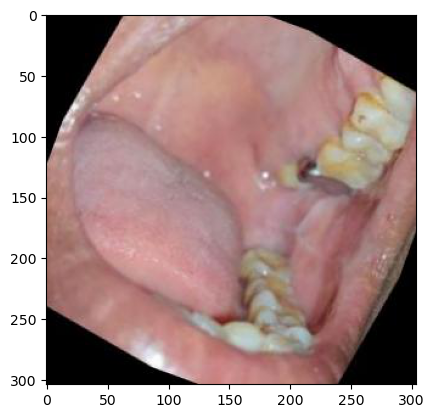

In [ ]:
# Caminho para as imagens
caminho_ben = "dados/Oral Images Dataset/augmented_data/augmented_benign/*.jpg"
caminho_mal = "dados/Oral Images Dataset/augmented_data/augmented_malignant/*.jpg"


# Lista com os caminhos de todos os arquivos
imagens_ben = glob.glob(caminho_ben)
imagens_mal = glob.glob(caminho_mal)


# Ler todas as imagens em uma lista
imagens_ben = [io.imread(img_path) for img_path in imagens_ben]
imagens_mal = [io.imread(img_path) for img_path in imagens_mal]


df_ben = pd.DataFrame({"path": imagens_ben, "label": 0})
df_mal = pd.DataFrame({"path": imagens_mal, "label": 1})
df = pd.concat([df_ben, df_mal], ignore_index=True)
# Exibir a primeira imagem
plt.imshow(imagens_ben[0])

### 🎯 **Split treino, validação e teste**

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class OralCancerDatasetDF(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["path"]
        label = int(self.df.iloc[idx]["label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
TAMANHO_VALIDACAO = 1/10
SEMENTE_ALEATORIA = 1110

class DataModule(L.LightningDataModule):
    def __init__(self, data_path: str = './'):
        super().__init__()
        self.data_path = data_path

        # transformação (tensorização)
        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

    ##########################################################
    #     Baixando os dados
    ##########################################################

        # descompacta os dados
        caminho_zip = 'mhjyrn35p4-2.zip'
        pasta_dados = "dados"
        try:
            with ZipFile(caminho_zip, 'r') as zip_obj:
                zip_obj.extractall(pasta_dados)
            print(f"Arquivos extraídos em '{pasta_dados}'.")
        except Exception as e:
            print(f"Erro ao descompactar: {e}")

        # monta DataFrame
        caminho_ben = os.path.join(pasta_dados, "Oral Images Dataset", "augmented_data", "augmented_benign", "*.jpg")
        caminho_mal = os.path.join(pasta_dados, "Oral Images Dataset", "augmented_data", "augmented_malignant", "*.jpg")

        imagens_ben = glob.glob(caminho_ben)
        imagens_mal = glob.glob(caminho_mal)

        df_ben = pd.DataFrame({"path": imagens_ben, "label": 0})
        df_mal = pd.DataFrame({"path": imagens_mal, "label": 1})
        self.df = pd.concat([df_ben, df_mal], ignore_index=True)

    def setup(self, stage=None):
        # from Dataset import OralCancerDatasetDF

        if stage == "fit" or stage is None:
            df_train, df_test = train_test_split(self.df, test_size=TAMANHO_VALIDACAO, random_state=SEMENTE_ALEATORIA)
            df_train, df_val = train_test_split(df_train, test_size=TAMANHO_VALIDACAO, random_state=SEMENTE_ALEATORIA)

            self.train = OralCancerDatasetDF(df_train, transform=self.transform)
            self.val = OralCancerDatasetDF(df_val, transform=self.transform)
            # self.test = OralCancerDatasetDF(df_test, transform=self.transform)

        if stage == "test" or stage is None:
            self.test = OralCancerDatasetDF(df_test, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.train, batch_size=64, shuffle=True, num_workers=0)

    def val_dataloader(self):
        return DataLoader(self.val, batch_size=64, num_workers=0)

    def test_dataloader(self):
        return DataLoader(self.test, batch_size=64, num_workers=0)


### 🏋🏻‍♀️**Treinando a rede: Sem otimização**

In [ ]:
TAXA_DE_APRENDIZADO = 0.001

class CNN(L.LightningModule):

    def __init__(
            self,
            cnn_out_channels=None, #filtros ou canais de saída
            n_lables: int = 2      # Modelo binário
    ):
        super().__init__() #inicializa com atributos já existentes no Lightning

        if cnn_out_channels is None:
            cnn_out_channels = [16, 32, 64] #determina o número padrão de filtros em cada camada

        #acurácia em cada etapa
        self.train_acc = Accuracy(task="binary")
        self.valid_acc = Accuracy(task="binary")
        self.test_acc = Accuracy(task="binary")

        in_channels = 3 #número de entradas por imagem - começa com ela inteira

        cnn_block = list() # lista para armazenar cada camada
        for out_channel in cnn_out_channels: #para cada camada
            cnn_block.append(
                nn.Conv2d( # camada convolucional
                    in_channels=in_channels, #entrada
                    out_channels=out_channel, # filtros aplicados
                    kernel_size=3,
                    stride=1,
                    padding=1
                )
            )
            cnn_block.append(nn.ReLU()) #função de ativação
            cnn_block.append(nn.MaxPool2d((2, 2))) # camada de pooling - reduz as dimensões
            in_channels = out_channel # para a próxima camada, a entrada será p número de filtros aplicados

        self.cnn_block = nn.Sequential(*cnn_block) # agrupa todas as camadas em sequência

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # reduz para 1x1 independentemente do tamanho da imagem
            nn.Flatten(),
            nn.Linear(cnn_out_channels[-1], 1),
            nn.Sigmoid()
        )

        #listas para salvar as labels na etapa de teste - serão usadas para visualização dos resultados
        self.y_true = []
        self.y_pred = []

    def forward(self, x): # passa os dados pela rede
        # é pré-determinado como __call__ do pytorch
        x = self.cnn_block(x)
        return self.head(x)

    def training_step(self, batch, batch_idx): #etapa de treino em lotes
        x, y = batch #separa atributo e target
        logits = self(x) #forward

        # CORREÇÃO: Ajustar shapes para serem compatíveis
        logits = logits.squeeze()  # Remove dimensão extra: [64, 1] -> [64]
        y = y.float()  # Garantir que y seja float

        loss_function = nn.BCELoss()
        loss = loss_function(logits, y)

        preds = (logits > 0.5).float() # previsão de classes: a que tem maior probabilidade

        self.train_acc.update(preds, y) #atualiza o valor da acurácia da classificação
        self.log("train_loss", loss, prog_bar=True) #mostra erro no terminal
        return loss #retorna o erro

    def on_training_epoch_end(self): #camada final de treinamento de uma época
        self.log("train_acc", self.train_acc.compute()) #cálcula a acurácia total da época
        self.train_acc.reset() #reseta a acurácia para a próxima época

    def validation_step(self, batch, batch_idx): #etapa de validação em lotes: avalia se o modelo está aprendendo ou não a cada época
        x, y = batch #separa atributo e target
        logits = self(x) #forward

        # CORREÇÃO: Ajustar shapes para serem compatíveis
        logits = logits.squeeze()  # Remove dimensão extra: [64, 1] -> [64]
        y = y.float()  # Garantir que y seja float

        loss_function = nn.BCELoss()
        loss = loss_function(logits, y)

        preds = (logits > 0.5).float() # previsão de classes: a que tem maior probabilidade
        self.valid_acc.update(preds, y) #atualiza o valor da acurácia da classificação
        self.log("valid_loss", loss, prog_bar=True) #mostra erro no terminal
        return loss #retorna o erro

    def on_validation_epoch_end(self): #camada final de validação de uma época
        self.log("valid_acc", self.valid_acc.compute(), prog_bar=True) #cálcula a acurácia total da época
        self.valid_acc.reset() #reseta a acurácia para a próxima época

    def test_step(self, batch, batch_idx): #etapa de treino em lotes:
        x, y = batch  #separa atributo e target
        #sava os dados caso se deseje visualizá-los depois
        self.x_test_data = x #atributos
        self.y_test_data = y #target
        logits = self(x) #forward

        # CORREÇÃO: Ajustar shapes para serem compatíveis
        logits = logits.squeeze()  # Remove dimensão extra: [64, 1] -> [64]
        y = y.float()  # Garantir que y seja float

        loss_function = nn.BCELoss()
        loss = loss_function(logits, y)

        self.preds = (logits > 0.5).float()  # previsão de classes: a que tem maior probabilidade
        self.test_acc.update(self.preds, y) #atualiza o valor da acurácia da classificação
        self.log("test_loss", loss, prog_bar=True)  #mostra erro no terminal
        self.log("test_acc", self.test_acc.compute(), prog_bar=True)  #mostra acurácia no terminal

        self.y_true.extend(y.tolist()) #salva as labels reais
        self.y_pred.extend(self.preds.tolist()) #salva as labels previstas

        return loss #retorna o erro

    def configure_optimizers(self): #calcula e altera os gradientes para todos os parâmetros treináveis da rede, de acordo com a  taxa de aprendizado
        optimizer = torch.optim.Adam(self.parameters(), lr=TAXA_DE_APRENDIZADO)
        return optimizer

In [ ]:
NUM_EPOCAS = 5

treinador = L.Trainer(max_epochs=NUM_EPOCAS) #determina o treinamento pelo número de épocas

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/julia24002/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [ ]:
dm = DataModule() #carrega e trata os dados
minha_cnn = CNN() #determina uma instância da classe CNN - determina a rede neural

Arquivos extraídos em 'dados'.


In [ ]:
treinador.fit(minha_cnn, dm) #treina a rede automaticamente com os dados de treino e validação, passando pelas etapas de treino e validaçõa a cada época


  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | train_acc | BinaryAccuracy | 0      | train
1 | valid_acc | BinaryAccuracy | 0      | train
2 | test_acc  | BinaryAccuracy | 0      | train
3 | cnn_block | Sequential     | 23.6 K | train
4 | head      | Sequential     | 65     | train
-----------------------------------------------------
23.6 K    Trainable params
0         Non-trainable params
23.6 K    Total params
0.095     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
SLURM auto-requeueing enabled. Setting signal handlers.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/julia24002/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
/home/julia24002/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
/home/julia24002/anaconda3/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


### 🐙**Otimização de hiperparâmetros**

In [ ]:
# ----------------------------
# Definição do modelo
# ----------------------------
class CNNLightning(L.LightningModule):
    def __init__(self,
                 n_conv_layers,
                 n_filters,
                 kernel_size,
                 activation_name,
                 dropout,
                 learning_rate,
                 input_channels,
                 input_height,
                 input_width,
                 num_classes=1):

        super().__init__()
        self.save_hyperparameters()

        # Função de ativação
        if activation_name.lower() == "relu":
            activation = nn.ReLU()
        elif activation_name.lower() == "sigmoid":
            activation = nn.Sigmoid()
        else:
            raise ValueError(f"Ativação {activation_name} não suportada")

        # Camadas convolucionais
        layers = []
        in_channels = input_channels
        for _ in range(n_conv_layers):
            layers.append(nn.Conv2d(in_channels, n_filters, kernel_size, padding=kernel_size//2))
            layers.append(activation)
            layers.append(nn.MaxPool2d(2))
            layers.append(nn.Dropout(dropout))
            in_channels = n_filters
        self.conv = nn.Sequential(*layers)

        # Calcula tamanho da saída da convolução
        self._conv_output_size = self._get_conv_output((input_channels, input_height, input_width))

        # Camada totalmente conectada
        self.fc = nn.Sequential(
            nn.Linear(self._conv_output_size, num_classes),
            nn.Sigmoid()
        )

        # Função de perda e learning rate
        self.loss_fn = nn.BCELoss()
        self.learning_rate = learning_rate

        # Métricas
        self.train_acc = Accuracy(task="binary")
        self.val_acc = Accuracy(task="binary")

    def _get_conv_output(self, shape):
        bs = 1
        x = torch.zeros(bs, *shape)
        x = self.conv(x)
        return int(torch.prod(torch.tensor(x.shape[1:])))

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y = y.unsqueeze(1).float()
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = (logits > 0.5).float()
        self.train_acc(preds, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y = y.unsqueeze(1).float()
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = (logits > 0.5).float()
        self.val_acc(preds, y)
        self.log("val_loss", loss, on_step=False, on_epoch=True)
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)


# ----------------------------
# Função objective para Optuna
# ----------------------------
def objective(trial):
    n_conv_layers = trial.suggest_int("n_conv_layers", 1, 3)
    n_filters = trial.suggest_int("n_filters", 16, 64)
    kernel_size = trial.suggest_int("kernel_size", 3, 5)
    activation_name = trial.suggest_categorical("activation_name", ["relu", "sigmoid"])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    # Substitua estas variáveis pelos seus DataLoaders originais
    # global train_loader, val_loader

    data_module = DataModule(data_path="./")
    data_module.setup("fit")
    train_loader = data_module.train_dataloader()
    val_loader = data_module.val_dataloader()

    # Obter tamanho das entradas (canais, altura, largura) de um batch
    sample_x, _ = next(iter(train_loader))
    input_channels, input_height, input_width = sample_x.shape[1], sample_x.shape[2], sample_x.shape[3]

    model = CNNLightning(
        n_conv_layers=n_conv_layers,
        n_filters=n_filters,
        kernel_size=kernel_size,
        activation_name=activation_name,
        dropout=dropout,
        learning_rate=learning_rate,
        input_channels=input_channels,
        input_height=input_height,
        input_width=input_width,
        num_classes=1
    )

    trainer = L.Trainer(
        max_epochs=10,
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=False,
        accelerator="auto",
    )

    trainer.fit(model, train_loader, val_loader)
    val_acc = trainer.callback_metrics["val_acc"].item()
    print(f"Rodando trial {trial.number} com parâmetros: {trial.params}")

    return val_acc


# ----------------------------
# Rodando Optuna
# ----------------------------
# study = optuna.create_study(
#                         direction="maximize",
#                         study_name = f"optimization_cnn_teste6",
#                         storage=f"sqlite:///optimization_cnn_teste6.db")

# optuna.logging.set_verbosity(optuna.logging.DEBUG)
# study.optimize(objective, n_trials=10)

# print("Melhores parâmetros:")
# print(study.best_trial.params)


### 🏋🏻‍♀️ **Treinamento do modelo otimizado**

In [ ]:
data_module = DataModule(data_path="./")
data_module.setup("fit")
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()

Arquivos extraídos em 'dados'.


In [ ]:
sample_x, _ = next(iter(train_loader))
input_channels, input_height, input_width = sample_x.shape[1], sample_x.shape[2], sample_x.shape[3]

In [ ]:
study_name = "optimization_cnn_teste6"
storage_url = "sqlite:///optimization_cnn_teste6.db"

study = optuna.load_study(study_name=study_name, storage=storage_url)

best_params = study.best_trial.params

modelo_otimizado = CNNLightning(
    n_conv_layers=best_params["n_conv_layers"],
    n_filters=best_params["n_filters"],
    kernel_size=best_params["kernel_size"],
    activation_name=best_params["activation_name"],
    dropout=best_params["dropout"],
    learning_rate=best_params["learning_rate"],
    input_channels=input_channels,
    input_height=input_height,
    input_width=input_width,
    num_classes=1
)

In [ ]:
class DataModule(L.LightningDataModule):
    def __init__(self, data_path: str = './', train_idx=None, val_idx=None):
        super().__init__()
        self.data_path = data_path
        self.train_idx = train_idx
        self.val_idx = val_idx

        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

        caminho_zip = 'mhjyrn35p4-2.zip'
        pasta_dados = "dados"
        try:
            with ZipFile(caminho_zip, 'r') as zip_obj:
                zip_obj.extractall(pasta_dados)
        except Exception as e:
            print(f"Erro ao descompactar: {e}")

        caminho_ben = os.path.join(pasta_dados, "Oral Images Dataset", "augmented_data", "augmented_benign", "*.jpg")
        caminho_mal = os.path.join(pasta_dados, "Oral Images Dataset", "augmented_data", "augmented_malignant", "*.jpg")

        imagens_ben = glob.glob(caminho_ben)
        imagens_mal = glob.glob(caminho_mal)

        df_ben = pd.DataFrame({"path": imagens_ben, "label": 0})
        df_mal = pd.DataFrame({"path": imagens_mal, "label": 1})
        self.df = pd.concat([df_ben, df_mal], ignore_index=True)

    def setup(self, stage=None):
        if stage == "fit" or stage is None:
            if self.train_idx is not None and self.val_idx is not None:
                df_train = self.df.iloc[self.train_idx]
                df_val = self.df.iloc[self.val_idx]
            else:
                df_train, df_val = train_test_split(
                    self.df, test_size=TAMANHO_VALIDACAO, random_state=SEMENTE_ALEATORIA
                )

            self.train = OralCancerDatasetDF(df_train, transform=self.transform)
            self.val = OralCancerDatasetDF(df_val, transform=self.transform)

        if stage == "test" or stage is None:
            self.test = OralCancerDatasetDF(self.df, transform=self.transform)
    def train_dataloader(self):
        return DataLoader(self.train, batch_size=64, shuffle=True, num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val, batch_size=64, shuffle=False, num_workers=2)

    def test_dataloader(self):
        return DataLoader(self.test, batch_size=64, shuffle=False, num_workers=2)


In [ ]:
NUM_FOLDS = 5
SEMENTE_ALEATORIA = 20404
kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEMENTE_ALEATORIA)

scores_acc = []

#     dm = DataModule(train_idx=train_idx, val_idx=val_idx)
#     dm.setup("fit")

X = np.arange(len(dm.df))
y = dm.df['label'].values

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n🔹 Fold {fold+1}/{NUM_FOLDS}")

    dm_fold = DataModule(train_idx=train_idx, val_idx=val_idx)
    dm_fold.setup("fit")

    modelo_fold = CNNLightning(n_conv_layers=best_params["n_conv_layers"],
                                n_filters=best_params["n_filters"],
                                kernel_size=best_params["kernel_size"],
                                activation_name=best_params["activation_name"],
                                dropout=best_params["dropout"],
                                learning_rate=best_params["learning_rate"],
                                input_channels=input_channels,
                                input_height=input_height,
                                input_width=input_width,
                                num_classes=1
                              )

    trainer = L.Trainer(
    max_epochs=10,
    enable_checkpointing=False,
    logger=True,
    enable_progress_bar=False,
    accelerator="auto"
)

    trainer.fit(modelo_fold, dm_fold)

    # Validação
    results = trainer.validate(modelo_fold, datamodule=dm_fold)
    val_acc = results[0]['val_acc']
    scores_acc.append(val_acc)

    print(f"Acurácia do fold {fold+1}: {val_acc:.4f}")

# Estatísticas finais
print("\nAcurácia média dos folds:", np.mean(scores_acc))
print("Desvio padrão da acurácia:", np.std(scores_acc))


🔹 Fold 1/5


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | conv      | Sequential     | 1.0 K  | train
1 | fc        | Sequential     | 485 K  | train
2 | loss_fn   | BCELoss        | 0      | train
3 | train_acc | BinaryAccuracy | 0      | train
4 | val_acc   | BinaryAccuracy | 0      | train
-----------------------------------------------------
486 K     Trainable params
0         Non-trainable params
486 K     Total params
1.945     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
SLURM auto-requeueing enabled. Setting signal handlers.
`Trainer.fit` stopped: `max_epochs=10` reached.
SLURM auto-requeueing enabled. Setting signal handlers.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.8237885236740112     │
│         val_loss          │    0.41331714391708374    │
└───────────────────────────┴───────────────────────────┘

Acurácia do fold 1: 0.8238

🔹 Fold 2/5


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | conv      | Sequential     | 1.0 K  | train
1 | fc        | Sequential     | 485 K  | train
2 | loss_fn   | BCELoss        | 0      | train
3 | train_acc | BinaryAccuracy | 0      | train
4 | val_acc   | BinaryAccuracy | 0      | train
-----------------------------------------------------
486 K     Trainable params
0         Non-trainable params
486 K     Total params
1.945     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
SLURM auto-requeueing enabled. Setting signal handlers.
`Trainer.fit` stopped: `max_epochs=10` reached.
SLURM auto-requeueing enabled. Setting signal handlers.


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.8127753138542175     │
│         val_loss          │    0.4194927513599396     │
└───────────────────────────┴───────────────────────────┘

Acurácia do fold 4: 0.8128

🔹 Fold 5/5


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | conv      | Sequential     | 1.0 K  | train
1 | fc        | Sequential     | 485 K  | train
2 | loss_fn   | BCELoss        | 0      | train
3 | train_acc | BinaryAccuracy | 0      | train
4 | val_acc   | BinaryAccuracy | 0      | train
-----------------------------------------------------
486 K     Trainable params
0         Non-trainable params
486 K     Total params
1.945     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
SLURM auto-requeueing enabled. Setting signal handlers.
`Trainer.fit` stopped: `max_epochs=10` reached.
SLURM auto-requeueing enabled. Setting signal handlers.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.8392070531845093     │
│         val_loss          │    0.3899349868297577     │
└───────────────────────────┴───────────────────────────┘

Acurácia do fold 5: 0.8392

Acurácia média dos folds: 0.8176211357116699
Desvio padrão da acurácia: 0.013245196189322902
